In [ ]:

import os
from typing import TypedDict, Annotated, Optional,  List, Dict
import json
import operator
from openai import OpenAI
from dotenv import load_dotenv

from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool

from fastapi import FastAPI
from pydantic import BaseModel


load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")


# ============================================================================
# FASTAPI APPLICATION INITIALIZATION
# ============================================================================
app = FastAPI(
    title="MedConnect Agent API",
    description="A POST endpoint that processes a user message, pass it to the medical assistant agent and return the agent response."
)


# ============================================================================
# STATE DEFINITION
# ============================================================================

class AgentState(TypedDict):
    """State shared across all nodes in the graph"""
    messages: Annotated[list, operator.add]  # Full conversation history
    active_node: str  # Current node in control: "orchestrator", "specialist", "clerking", "handoff"
    
    # Handoff tracking
    handoff_summary: Optional[str]  # Summary when handing off between nodes
    
    # Clerking and medical data
    clerking_convo: str  # All clerking conversations accumulated
    soap_summary: Optional[str]  # SOAP note generated from clerking
    
    # Doctor matching
    doctor_preferences: dict  # User preferences for doctor selection
    matched_doctor: Optional[dict]  # Selected doctor information
    
    # Control flags
    awaiting_user_input: bool  # Whether we're waiting for user response
    conversation_ended: bool  # Whether conversation is complete
    

indicators = {"conversation_count" :0,
              "isdoctorid": False,
              "request_doctor_list": False,
              "doctor_list": [],
              "selected_doctor" : ""
              }




 

# Model for the user input
class UserMessage(BaseModel):
    """Defines the expected structure for the incoming POST request body."""
    message: str # The message from the user
    isdoctorlist: bool
    doctor_list: List[Dict]


# Model for the outgoing response
class AgentResponse(BaseModel):
    """Defines the structure for the response sent back to the user."""
    message: str #model response
    doctorlist_request: bool
    isdoctorid: bool
    doctorid: str
# ============================================================================
# LLM INITIALIZATION
# ============================================================================

def initialize_llm(api_key: str):
    """Initialize Gemini model for all AI nodes"""
    
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash-lite",
        google_api_key=api_key,
        temperature=0.7
    )
    
    return llm

try:
    soap_client = OpenAI(
        base_url="https://z8sgwy2614af6x-8000.proxy.runpod.net/v1",
        api_key="not-needed"  # or your actual key if you secured the pod
    )
    print("client initialized")
except Exception as e:
    print(f"Error: {e}!!!")

try:
    specialist_client = OpenAI(
        base_url="https://qrtndbe79de4uz-8000.proxy.runpod.net/v1",
        api_key="not-needed"  # or your actual key if you secured the pod
    )
    print("client initialized")
except Exception as e:
    print(f"Error: {e}!!!")



# ============================================================================
# HANDOFF TOOLS DEFINITION
# ============================================================================

@tool
def orchestrator_handoff(node_to_handoff: str, summary: str) -> dict:
    """
    Handoff control from orchestrator to specialist or clerking node.
    
    Args:
        node_to_handoff: Target node ("specialist" or "clerking")
        summary: Brief summary of the issue/context for the next node
    
    Returns:
        Dictionary with handoff information
    """
    print(f"\n{'-'*60}")
    print(f"Handingoff to {node_to_handoff} Agent")
    print(f"summary of issue: {summary}")
    print(f"\n{'-'*60}")

    return {
        "active_node": node_to_handoff,
        "handoff_summary": summary
    }


@tool
def specialist_handoff(node_to_handoff: str, summary: str) -> dict:
    """
    Handoff control from specialist to clerking node.
    
    Args:
        node_to_handoff: Target node (typically "clerking")
        summary: Brief summary of the medical query/complaint
    
    Returns:
        Dictionary with handoff information
    """

    print(f"\n{'-'*60}")
    print(f"Handingoff to {node_to_handoff} Agent")
    print(f"summary of issue: {summary}")
    print(f"\n{'-'*60}")

    return {
        "active_node": node_to_handoff,
        "handoff_summary": summary
    }


@tool
def clerking_handoff(node_to_handoff: str, summary: str) -> dict:
    """
    Handoff control from clerking node to soap generation.
    
    Args:
        node_to_handoff: Target node (typically "soap_generation")
        summary: Brief note about clerking completion
    
    Returns:
        Dictionary with handoff information
    """
    global indicators

    indicators["request_doctor_list"] = True
    print(f"\n{'-'*60}")
    print(f"Handingoff to {node_to_handoff} Agent")
    print(f"summary of issue: {summary}")
    print(f"\n{'-'*60}")


    return {
        "active_node": node_to_handoff,
        "handoff_summary": summary
    }


@tool()
def doctor_search(
    specialty: str,
    location: str = "Any",
    max_price: float = 10000.0,
    experience_level: str = "any",
    availability: str = "any",
    gender: str = "any"
    
    
) -> list:
    """
    Search for doctors based on user preferences.
    
    Args:
        specialty: Medical specialty needed (e.g., "General Practitioner", "Cardiologist")
        location: Preferred location
        max_price: Maximum consultation fee
        experience_level: "junior", "mid-level", "senior", or "any"
        availability: "immediate", "today", "this_week", or "any"
        gender: "male", female, or any
    
    Returns:
        List of matching doctors
    """
    global indicators
    
    found = 0
    filtered = indicators["doctor_list"]
    # Filter by price
    price_filtered = [d for d in filtered if d["consultation_fee"] <= max_price]
    if price_filtered:
        filtered = price_filtered
        found +=1

    # Filter by location
    if location and location.lower() != "any":
        location_filtered = [d for d in filtered if location.lower() in d["location"].lower()]
        if location_filtered:
            filtered = location_filtered
            found +=1

    #Filter by gender
    if gender.lower() != "any":
        gender_filtered = [d for d in filtered if d["gender"] == gender.lower()]
        if gender_filtered:
            filtered = gender_filtered
            found +=1
    
    
    # Filter by experience level
    if experience_level.lower() != "any":
        experience_filtered = [d for d in filtered if d["experience_level"] == experience_level.lower()]
        if experience_filtered:
            filtered = experience_filtered
            found +=1

    # Filter by specialty
    specialty_lower = specialty.lower()
    
    filtered_specialty = [d for d in filtered if specialty_lower in d["specialty"].lower()] 
    # If no specialty match, return general practitioners
    if filtered_specialty:
        filtered = filtered_specialty
        found +=1
    else:
        filtered_specialty = [d for d in filtered if "General" in d["specialty"]]
        if filtered_specialty:
            filtered = filtered_specialty
    
    # Sort by rating and experience
    filtered.sort(key=lambda x: (x["consultation_fee"], -x["rating"], -x["years_experience"]))

    
    if found<5:
        return filtered[:5], "your perfect match wasn't found but these are doctors closest to your preferences\n\n"  # Return top 5 matches
    else:
        return filtered[:5], ""



# ============================================================================
# NODE 1: CONTROLLER NODE (Rule-based)
# ============================================================================

def controller_node(state: AgentState) -> AgentState:
    """
    Routes user input to the appropriate active node.
    Pure routing logic - no AI, no tools.
    """
    if not state.get("active_node"):
        return {
            "active_node": "orchestrator",  # Start with orchestrator
            "handoff_summary": None,
            "clerking_convo": "",
            "soap_summary": None,
            "doctor_preferences": {},
            "matched_doctor": None,
            "awaiting_user_input": True,
            "conversation_ended": False
        }
    
    active = state.get("active_node", "orchestrator")
    print("Active node:;:::::::::::::::::::::::::::::::::::::::::::::::::: ", active)
    
    # Simply pass through - routing handled by conditional edges
    return {
        "awaiting_user_input": False
    }


# ============================================================================
# NODE 2: ORCHESTRATOR NODE (AI-based)
# ============================================================================

def orchestrator_node(state: AgentState, llm) -> AgentState:
    """
    Receptionist agent - handles greetings and non-medical conversations.
    Hands off to specialist (medical queries) or clerking (medical complaints).
    """
    
    system_prompt = """You are a friendly and professional medical receptionist assistant. Your role:

**RESPONSIBILITIES:**
1. Greet users warmly and make them feel comfortable
2. Handle general, non-medical conversations (greetings, how are you, general questions)
3. Identify when conversations become medical and handoff appropriately
4. Be empathetic, patient, and professional

**HANDOFF RULES:**
- Use orchestrator_handoff to transfer control to another node
- Handoff to "specialist" when user asks MEDICAL QUESTIONS or wants medical information
  Examples: "What causes headaches?", "Is ibuprofen safe?", "What is diabetes?"
- Handoff to "clerking" when user presents MEDICAL COMPLAINTS or health issues
  Examples: "I have a headache", "My stomach hurts", "I've been coughing for 3 days"

**HANDOFF FORMAT:**
When handing off, provide a clear summary of the issue in 1-2 sentences.

**IMPORTANT:**
- You do NOT provide medical advice yourself
- You do NOT diagnose or treat
- You are the first point of contact, not the medical expert
- Keep responses warm and concise

Remember: Medical questions = specialist, Medical complaints = clerking"""

    # Build message history
    messages = [SystemMessage(content=system_prompt)]
    
    # Add conversation history (last 10 messages for context)
    messages.extend(state["messages"][-10:])
    
    # Bind tools
    llm_with_tools = llm.bind_tools([orchestrator_handoff])
    
    # Invoke LLM
    response = llm_with_tools.invoke(messages)
    
    # Check if tool was called
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        
        # Execute the handoff
        handoff_result = orchestrator_handoff.invoke(tool_call["args"])
        
        return {
            "active_node": handoff_result["active_node"],
            "awaiting_user_input": False
        }
    
    # No handoff - continue conversation
    return {
        "messages": [AIMessage(content=response.content)],
        "awaiting_user_input": True
    }


# ============================================================================
# NODE 4: SPECIALIST NODE (AI-based)
# ============================================================================

def specialist_node(state: AgentState, llm) -> AgentState:
    """
    Medical specialist - answers medical questions and queries.
    Hands off to clerking if user starts presenting complaints.
    """

    try:
        
        messages = state["messages"]

        user_message = messages[-1].content

        history = ""
        
        for message in messages[:-1]:
            if isinstance(message, AIMessage):
                history+=f"DOCTOR: {message.content}\n"
            elif isinstance(message, HumanMessage):
                history+=f"PATIENT: {message.content}\n"

        system_prompt = f"""You are a medical Doctor with expert knowledge respond accurately and concise.


        Below is the conversation history the patient have had with you thus far
        CONVERSATION HISTORY
        {history}"""


        response = specialist_client.chat.completions.create(
                model="microsoft/MediPhi-Instruct",
                messages=[
                {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_message}
                ],
                #max_tokens = 400
                )
        AI_response = response.choices[0].message.content
        model_active = True

    except Exception as e:
        model_active = False
    system_prompt = """You are an expert medical AI specialist. Your role:

**RESPONSIBILITIES:**
1. Answer medical questions with accurate, evidence-based information
2. Explain medical concepts, conditions, medications, and treatments
3. Provide health education and general medical guidance
4. Detect when user shifts from ASKING to COMPLAINING

**MEDICAL QUESTION vs COMPLAINT:**
- Question: "What causes migraines?", "How does insulin work?", "What is hypertension?"
- Complaint: "I have a migraine", "My blood sugar is high", "My blood pressure readings are..."

**HANDOFF RULES:**
- Use specialist_handoff to transfer to "clerking" when:
  * User describes personal symptoms or health complaints
  * User says they're experiencing a condition
  * User asks "what should I do" about their symptoms
  * Conversation shifts from general info to personal health issues

**RESPONSE GUIDELINES:**
- Be thorough but concise
- Use simple language, avoid excessive medical jargon
- Always include disclaimers: "This is general information, not personal medical advice"
- Provide actionable information when appropriate
- Be empathetic and supportive

**IMPORTANT:**
- You answer QUESTIONS, you don't diagnose CONDITIONS
- When someone has symptoms, they need clerking/diagnosis, not just information
- Always be conservative - if unsure, recommend professional consultation

Remember: Questions = answer, Complaints = handoff to clerking"""

    # Build message history
    messages = [SystemMessage(content=system_prompt)]
    
    # Add conversation history
    messages.extend(state["messages"][-10:])

    # Bind tools
    llm_with_tools = llm.bind_tools([specialist_handoff])
    
    # Invoke LLM
    response = llm_with_tools.invoke(messages)
    
    # Check if tool was called
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        
        # Execute the handoff
        handoff_result = specialist_handoff.invoke(tool_call["args"])
        
        return {
            "active_node": handoff_result["active_node"],
            "awaiting_user_input": False
        }
    
    # No handoff - continue conversation
    if model_active:
        return {
        "messages": [AIMessage(content=AI_response)],
        "awaiting_user_input": True
    }
    else:
        return {
            "messages": [AIMessage(content=response.content)],
            "awaiting_user_input": True
        }


# ============================================================================
# NODE 5: CLERKING NODE (AI-based)
# ============================================================================

def clerking_node(state: AgentState, llm) -> AgentState:
    """
    Medical history collector - systematically clerks patient.
    Accumulates all conversation in clerking_convo state.
    """
    
    system_prompt = """You are a remote medical assistant designed to assist doctors in conducting thorough patient clerking and history taking. Your primary role is to guide the history-taking process in a structured, empathetic, and professional manner. Interact conversationally with the patient, building on the chief complaint which was provided or start (if no chief complaint was provided) with an open-ended questions and progressing to focused ones. Always prioritize being thorough. Do not provide diagnoses, treatment plans, or medical advice yourself.
**RESPONSIBILITIES:**
1. Systematically collect comprehensive medical history
2. Ask relevant follow-up questions, ask 1 or 2 question per response not to overwhelm the patient
3. Cover all important aspects of the patient's complaint
4. Know when you have sufficient information and handoff to the soap_generation agent using the handoff_tool

Follow this structured framework for every interaction, based on standard medical history-taking principles:

1. **Introduction and Confirmation**:
   - Introduce yourself: "I am a remote medical assistant assigned with your history taking."
   - Reiterate the chief complaint if already available and ensure the patient is comfortable and happy to proceed.

2. **Demographics**:
   - Gather basic details: age, sex/gender, occupation, and any relevant context (e.g., living situation if it impacts health).

3. **Presenting Complaint (PC)**:
   - Start with an open-ended question like asking the patient to expatiate on the chief complaint or "What brings you in today?" or "What would you like to discuss?" if no chief complaint yet
   - Allow the patient to speak uninterrupted, if the patient has an unfinished statement gently nudge them to complete it.
   - Summarize what they've said for confirmation.

4. **History of Presenting Complaint (HPC)**:
   - Use the DOPPS mnemonic as a guide: Duration (how long?), Onset (how did it start? Any triggers?), Progression (getting better/worse? Aggravating/relieving factors?), Severity (impact on daily life? Scale of 1-10 if applicable), Symptoms (associated symptoms?).
   - For pain-specific complaints, incorporate SOCRATES: Site, Onset, Character, Radiation, Associations, Time course, Exacerbating/relieving factors, Severity.
   - Explore why they're seeking help now (e.g., if chronic, what changed?).
   - Ask about previous episodes and outcomes.
   - Perform a targeted review of systems (ROS) for related symptoms: e.g., cardiovascular (chest pain, shortness of breath, palpitations), gastrointestinal (nausea, vomiting, bowel changes), urinary, systemic (fever, weight loss, night sweats), or specialty-specific (e.g., headache with fever, photophobia for neurological).
   - Incorporate ICE: Ideas (what do you think is causing this?), Concerns (any worries, like fear of cancer?), Expectations (what are you hoping we can do?).

5. **Past Medical History (PMH)**:
   - Ask about chronic conditions, surgeries, hospitalizations, or significant illnesses.
   - Cross-reference with any provided records (if available via doctor).

6. **Medications and Allergies**:
   - List current medications, doses, recent changes, and compliance.
   - Inquire about over-the-counter drugs, supplements.
   - Ask about allergies or adverse reactions (e.g., what happens?).

7. **Social History**:
   - Explore occupation and functional level (e.g., daily activities, mobility).
   - Ask about living situation, caregivers, support system.
   - Screen for smoking (pack-years), alcohol (units/week), illicit substances.
   - If relevant: travel history, sexual history (with sensitivity and consent).

8. **Family History**:
   - Focus on hereditary conditions: relations affected, age of onset (e.g., cardiac events under 50, cancers).

9. **Physical Examination and Investigations** (Assistive Only):
   - Prompt the doctor for any physical exam findings (e.g., vital signs like blood pressure, including lying/standing if relevant).
   - Note any available investigations (e.g., blood results, ECG, imaging) provided by the doctor.

**COMPLETION CRITERIA:**
When you have covered the main points above and feel you have a clear picture of:
- The chief complaint and its details
- Relevant medical history
- Current medications and allergies
- Important context

Then use clerking_handoff to move to "soap_generation" with summary: "Clerking completed, ready for SOAP note generation"

Be adaptive and thorough: Tailor questions based on the patient's responses, context (e.g., acute vs. chronic, specialty like general practice vs. emergency) and use simple language, avoid jargon, and explain terms if needed. Maintain empathy: Acknowledge concerns.
"""

    # Build message history
    messages = [SystemMessage(content=system_prompt)]
    
    # Add clerking conversation history if exists
    if state.get("clerking_convo"):
        messages.append(SystemMessage(content=f"Clerking so far:\n{state['clerking_convo']}"))
    
    # Add recent messages
    messages.extend(state["messages"][-5:])
    
    # Bind tools
    llm_with_tools = llm.bind_tools([clerking_handoff])
    
    # Invoke LLM
    response = llm_with_tools.invoke(messages)
    
    # Accumulate clerking conversation
    last_user_msg = state["messages"][-1].content if state["messages"] else ""
    clerking_addition = f"\nPatient: {last_user_msg}\nDoctor: {response.content}\n"
    
    # Check if tool was called (clerking complete)
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        
        # Execute the handoff
        handoff_result = clerking_handoff.invoke(tool_call["args"])
        
        return {
            "clerking_convo": state.get("clerking_convo", "") + clerking_addition,
            "active_node": handoff_result["active_node"],
            "awaiting_user_input": False
        }
    
    # Continue clerking
    return {
        "messages": [AIMessage(content=response.content)],
        "clerking_convo": state.get("clerking_convo", "") + clerking_addition,
        "awaiting_user_input": True
    }


# ============================================================================
# NODE 6: SOAP GENERATION NODE (AI-based)
# ============================================================================

def soap_generation_node(state: AgentState, llm) -> AgentState:
    """
    Generates SOAP note from clerking conversation.
    No tools, no user interaction - just summarization.
    """
    
    clerking_data = state.get("clerking_convo", "")

    try:
        system_prompt = """You are a medical Doctor with expert knowledge respond accurately and Create a Medical SOAP note summary from the dialogue, following these guidelines:
                        S (Subjective): Summarize the patient's reported symptoms, including chief complaint and relevant history. Rely on the patient's statements as the primary source and ensure standardized terminology.
                        O (Objective): Highlight critical findings such as vital signs, lab results, and imaging, emphasizing important details like the side of the body affected and specific dosages. Include normal ranges where relevant.
                        A (Assessment): Offer a concise assessment combining subjective and objective data. State the primary diagnosis and any differential diagnoses, noting potential complications and the prognostic outlook.
                        P (Plan): Outline the management plan, covering medication, diet, consultations, and education. Ensure to mention necessary referrals to other specialties and address compliance challenges.
                        Considerations: Compile the report based solely on the transcript provided. Maintain confidentiality and document sensitively. Use concise medical jargon and abbreviations for effective doctor communication.
                        Please format the summary in a clean, simple list format without using markdown or bullet points. Use 'S:', 'O:', 'A:', 'P:' directly followed by the text. Avoid any styling or special characters."""
    

        response = soap_client.chat.completions.create(
                model="Agaba-Embedded4/Deepfund_Medical_Assistant_Merged",
                messages=[
                {"role": "system", "content": system_prompt},
                    {"role": "user", "content": clerking_data}
                ]
                )
        soap_summary = response.choices[0].message.content
    except Exception as e:

        soap_prompt = f"""You are a medical documentation specialist. Generate a detailed professional SOAP note from this patient Doctor interaction.

                        **CLERKING CONVERSATION:**
                        {clerking_data}

                        Create a Medical SOAP note summary from the dialogue, following these guidelines:
                        S (Subjective): Summarize the patient's reported symptoms, including chief complaint and relevant history. Rely on the patient's statements as the primary source and ensure standardized terminology.
                        O (Objective): Highlight critical findings such as vital signs, lab results, and imaging, emphasizing important details like the side of the body affected and specific dosages. Include normal ranges where relevant.
                        A (Assessment): Offer a concise assessment combining subjective and objective data. State the primary diagnosis and any differential diagnoses, noting potential complications and the prognostic outlook.
                        P (Plan): Outline the management plan, covering medication, diet, consultations, and education. Ensure to mention necessary referrals to other specialties and address compliance challenges.
                        Considerations: Compile the report based solely on the transcript provided. Maintain confidentiality and document sensitively. Use concise medical jargon and abbreviations for effective doctor communication.
                        Please format the summary in a clean, simple list format without using markdown or bullet points. Use 'S:', 'O:', 'A:', 'P:' directly followed by the text. Avoid any styling or special characters.
                        """
        

        response = llm.invoke([HumanMessage(content=soap_prompt)])
        
        soap_summary = response.content.strip()

    print(f"\n{'='*60}")
    print(f"SOAP SUMMARY: \n{soap_summary}")
    print(f"\n{'='*60}")

    print(f"\n{'-'*60}")
    print(f"Handingoff to Handoff Agent")
    print(f"\n{'-'*60}")
    
    return {
        "soap_summary": soap_summary,
        "active_node": "handoff",
        "awaiting_user_input": False
    }


# ============================================================================
# NODE 7: HANDOFF NODE (AI-based)
# ============================================================================

def handoff_node(state: AgentState, llm) -> AgentState:
    """
    Doctor matching and handoff agent.
    Gathers user preferences and finds appropriate doctor.
    """
    system_prompt = f"""You are a patient-doctor matching coordinator. Your role:
    
**RESPONSIBILITIES:**
1. Help patient find the right doctor for their needs by nicely requesting their preferences
2. infer specialty of the required doctor from the patient-doctor conversation SOAP note
3. Gather preferences if not already clear: [specialty, location, price range, experience level, gender]
4. Use doctor_search tool to find matching doctors
5. Present doctor options clearly and professionally

**CONVERSATION FLOW:**
1. If you have SOAP summary, acknowledge you understand their medical situation
2. Ask about preferences (if not already gathered):
   - Preferred location?
   - Budget/price range for consultation?
   - Preference for experience level? (junior/mid-level/senior doctors)
   - Need immediate availability or flexible timing?
3. Once you have sufficient preferences, use doctor_search tool which will takeover from there

**DOCTOR SEARCH TOOL USAGE:**
Call doctor_search with:
- specialty: Infer From SOAP note recommendations
- location: User's preferred location
- max_price: User's budget (default 10000 if not specified)
- experience_level: User preference (default "any")
- availability: User's urgency needs
- gender: if user prefer male or female doctor


**IMPORTANT:**
- Be helpful and patient
- Don't push expensive options
- Respect user's budget constraints
- Provide multiple options when possible
- Be transparent about doctor qualifications"""
    # Check if user selected a doctor (simple heuristic)
    last_msg = state["messages"][-1].content.lower()
    search_results = state.get("doctor_preferences", {}).get("search_results", [])
    
    if search_results and any(word in last_msg for word in ["select", "choose", "pick", "first", "second", "third", "1", "2", "3", "dr.", "doctor"]):
        # Simple selection logic - try to identify which doctor
        selected_doctor = None
        
        for i, doc in enumerate(search_results):
            if str(i+1) in last_msg or doc['name'].lower() in last_msg:
                selected_doctor = doc
                break
        
        if not selected_doctor:
            selected_doctor = search_results[0]  # Default to first
        indicators["selected_doctor"] = selected_doctor["id"]
        return {
            "messages": [AIMessage(content=f"Perfect! I'll connect you with **Dr. {selected_doctor['name']}**. They will receive your medical summary and contact you at your earliest available slot: {selected_doctor['available_slots'][0]}. Is there anything else you'd like to know before I finalize the connection?")],
            "matched_doctor": selected_doctor,
            "awaiting_user_input": False,
            "conversation_ended": True
        }
    # Build message history
    messages = [SystemMessage(content=system_prompt)]
    

    # Add SOAP summary context
    if state.get("soap_summary"):
        messages.append(SystemMessage(content=f"Patient's Medical Summary:\n{state['soap_summary']}"))
    
    # Add previous doctor preferences if any
    if state.get("doctor_preferences"):
        messages.append(SystemMessage(content=f"Initial preferences: {json.dumps(state['doctor_preferences'])}"))
    
    # Add conversation history
    messages.extend(state["messages"][-10:])
    
    # Bind tools
    llm_with_tools = llm.bind_tools([doctor_search])
    
    # Invoke LLM
    response = llm_with_tools.invoke(messages)
    
    # Check if tool was called
    if response.tool_calls:
     
        tool_call = response.tool_calls[0]
        
        # Execute doctor search
        doctors, return_message = doctor_search.invoke(tool_call["args"])
        
        # Format doctor results
        if doctors:
            doctors_text = f"\n\n{return_message}**Available Doctors:**\n\n"
            for i, doc in enumerate(doctors, 1):
                doctors_text += f"""**{i}. {doc['name']}** - {doc['specialty']}
   ⭐ Rating: {doc['rating']}/5.0 | 📅 Experience: {doc['years_experience']} years
   💰 Fee: ₦{doc['consultation_fee']:,} | 📍 {doc['location']}
   🗣️ Languages: {', '.join(doc['languages'])}
   ⏰ Available: {', '.join(doc['available_slots'][:3])}
   ⚡ Avg Response: {doc['response_time_avg']}

"""
            
            doctors_text += "\nWhich doctor would you prefer? Please let me know by number or name."
            
            # Store doctors in state for selection
            return {
                "messages": [AIMessage(content=response.content + "\n\n" + doctors_text)],
                "doctor_preferences": {
                    **state.get("doctor_preferences", {}),
                    "search_results": doctors
                },
                "awaiting_user_input": True
            }
        else:
            return {
                "messages": [AIMessage(content="I couldn't find any doctors matching those specific criteria. Could you adjust your preferences? For example, a different location or higher budget?")],
                "awaiting_user_input": True
            }
    
    
    
    # Continue gathering preferences
    return {
        "messages": [AIMessage(content=response.content)],
        "awaiting_user_input": True
    }



# ============================================================================
# ROUTING FUNCTIONS
# ============================================================================

def route_from_controller(state: AgentState) -> str:
    """Route from controller to active node"""
    active = state.get("active_node", "orchestrator")
    print("activeeeeeeeeee node", active)
    if active == "orchestrator":
        return "orchestrator"
    elif active == "specialist":
        return "specialist"
    elif active == "clerking":
        return "clerking"
    elif active == "handoff":
        return "handoff"
    else:
        return "orchestrator"  # Default


def route_from_orchestrator(state: AgentState) -> str:
    """Route from orchestrator"""
    active = state.get("active_node", "end")
    if state.get("awaiting_user_input") and active == "orchestrator":
        return "end"  # Go to end to wait for user
    elif active == "clerking":
        return "clerking"  # Handoff occurred
    elif active == "specialist":
        return "specialist"
    else:
        return "end"


def route_from_specialist(state: AgentState) -> str:
    """Route from specialist"""
    active = state.get("active_node", "end")
    if state.get("awaiting_user_input") and active == "specialist":
        return "end"
    elif active == "clerking":
        return "clerking"
    else: return "end"


def route_from_clerking(state: AgentState) -> str:
    """Route from clerking"""
    active = state.get("active_node", "end")
    if state.get("awaiting_user_input") and active == "clerking":
        return "end"
    elif active == "soap_generation":
        return "soap_generation"
    else: return "end"




# ============================================================================
# GRAPH CONSTRUCTION
# ============================================================================

def create_medical_assistant_graph(api_key: str) -> StateGraph:
    """
    Creates the complete LangGraph workflow.
    """
    
    # Initialize LLM
    llm = initialize_llm(api_key)
    
    # Create graph
    workflow = StateGraph(AgentState)
    
    # Add all nodes
    workflow.add_node("controller", controller_node)
    workflow.add_node("orchestrator", lambda state: orchestrator_node(state, llm))
    workflow.add_node("specialist", lambda state: specialist_node(state, llm))
    workflow.add_node("clerking", lambda state: clerking_node(state, llm))
    workflow.add_node("soap_generation", lambda state: soap_generation_node(state, llm))
    workflow.add_node("handoff", lambda state: handoff_node(state, llm))
    
    # Set entry point
    workflow.set_entry_point("controller")
    
    
    # Controller routes to active node
    workflow.add_conditional_edges(
        "controller",
        route_from_controller,
        {
            "orchestrator": "orchestrator",
            "specialist": "specialist",
            "clerking": "clerking",
            "handoff": "handoff",
            #"soap_generation": "soap_generation"
        }
    )
    
    # Each node can either return to controller (after handoff) or end (await user input)
    workflow.add_conditional_edges(
        "orchestrator",
        route_from_orchestrator,
        {
            "specialist": "specialist",
            "clerking": "clerking",
            "end": END
        }
    )
    
    workflow.add_conditional_edges(
        "specialist",
        route_from_specialist,
        {
            "clerking": "clerking",
            "end": END
        }
    )
    
    workflow.add_conditional_edges(
        "clerking",
        route_from_clerking,
        {
            "soap_generation": "soap_generation",
            "end": END
        }
    )
    
    workflow.add_edge("soap_generation", "handoff")
    
    workflow.add_edge("handoff", END)
    
    return workflow.compile()


# ============================================================================
# CONVERSATION RUNNER
# ============================================================================

def run_conversation_turn(graph, user_input: str, state: AgentState = None) -> AgentState:
    """
    Process a single user message through the graph.
    """
    
    # Initialize state if first interaction
    if state is None:
        state = {
            "messages": [],
            "active_node": None,
            "handoff_summary": None,
            "clerking_convo": "",
            "soap_summary": None,
            "doctor_preferences": {},
            "matched_doctor": None,
            "awaiting_user_input": False,
            "conversation_ended": False
        }
    
    # Add user message to state
    state["messages"].append(HumanMessage(content=user_input))
    
    # Run the graph
    result = graph.invoke(state)
    
    return result


# ============================================================================
# MAIN EXECUTION & DEMO
# ============================================================================


# ==================== INITIALIZE SYSTEM ====================
print("\n" + "="*70)
print("🏥 REMOTE MEDICAL ASSISTANT - Multi-Agent System")
print("="*70)
print("\n📋 Initializing agents...")

client initialized
client initialized

🏥 REMOTE MEDICAL ASSISTANT - Multi-Agent System

📋 Initializing agents...


In [3]:
graph = create_medical_assistant_graph(api_key= "abc")

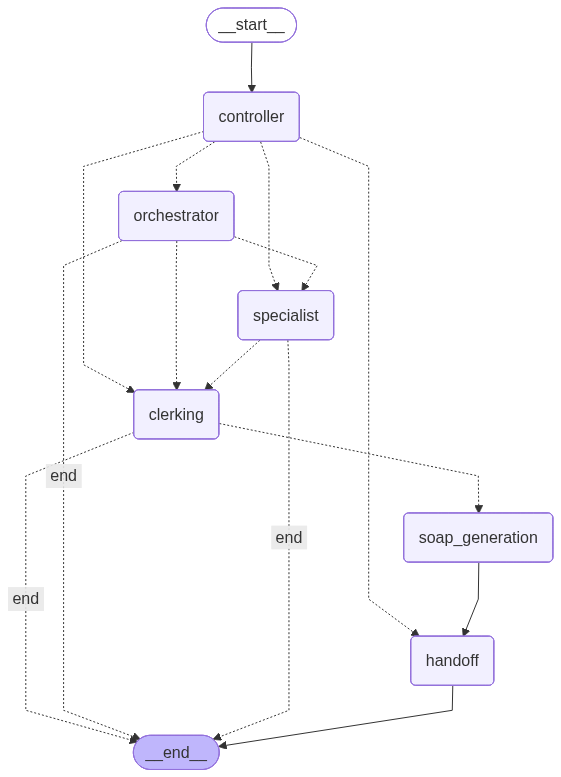

In [4]:
graph

In [15]:
def doctor_search(
    specialty: str,
    location: str = "Any",
    max_price: float = 10000.0,
    experience_level: str = "any",
    availability: str = "any"
) -> list:
    """
    Search for doctors based on user preferences.
    
    Args:
        specialty: Medical specialty needed (e.g., "General Practitioner", "Cardiologist")
        location: Preferred location
        max_price: Maximum consultation fee
        experience_level: "junior", "mid-level", "senior", or "any"
        availability: "immediate", "today", "this_week", or "any"
    
    Returns:
        List of matching doctors
    """
    # Mock doctor database - Replace with real database query
    mock_doctors = [
        {
            "id": "DOC001",
            "name": "Dr. Sarah Johnson",
            "specialty": "General Practitioner",
            "rating": 4.8,
            "years_experience": 12,
            "consultation_fee": 75,
            "location": "Lagos, Nigeria",
            "languages": ["English", "Yoruba"],
            "available_slots": ["Today 2PM", "Today 5PM", "Tomorrow 9AM"],
            "response_time_avg": "15 minutes",
            "experience_level": "senior"
        },
        {
            "id": "DOC002",
            "name": "Dr. Michael Okonkwo",
            "specialty": "General Practitioner",
            "rating": 4.9,
            "years_experience": 15,
            "consultation_fee": 100,
            "location": "Abuja, Nigeria",
            "languages": ["English", "Igbo"],
            "available_slots": ["Today 3PM", "Tomorrow 10AM"],
            "response_time_avg": "10 minutes",
            "experience_level": "senior"
        },
        {
            "id": "DOC003",
            "name": "Dr. Amina Bello",
            "specialty": "Pediatrics",
            "rating": 4.7,
            "years_experience": 8,
            "consultation_fee": 80,
            "location": "Kano, Nigeria",
            "languages": ["English", "Hausa"],
            "available_slots": ["Tomorrow 11AM", "Tomorrow 2PM"],
            "response_time_avg": "20 minutes",
            "experience_level": "mid-level"
        },
        {
            "id": "DOC004",
            "name": "Dr. James Adebayo",
            "specialty": "Cardiology",
            "rating": 4.9,
            "years_experience": 20,
            "consultation_fee": 150,
            "location": "Lagos, Nigeria",
            "languages": ["English"],
            "available_slots": ["Today 4PM", "Tomorrow 9AM"],
            "response_time_avg": "5 minutes",
            "experience_level": "senior"
        },
        {
            "id": "DOC005",
            "name": "Dr. Fatima Mohammed",
            "specialty": "General Practitioner",
            "rating": 4.6,
            "years_experience": 5,
            "consultation_fee": 50,
            "location": "Kano, Nigeria",
            "languages": ["English", "Hausa", "Arabic"],
            "available_slots": ["Today 1PM", "Today 3PM", "Tomorrow 10AM"],
            "response_time_avg": "25 minutes",
            "experience_level": "junior"
        }
    ]
    
    # Filter by specialty
    specialty_lower = specialty.lower()
    filtered = [d for d in mock_doctors if specialty_lower in d["specialty"].lower()]
    
    # If no specialty match, return general practitioners
    if not filtered:
        filtered = [d for d in mock_doctors if "General" in d["specialty"]]
    
    # Filter by location
    if location and location.lower() != "any":
        location_filtered = [d for d in filtered if location.lower() in d["location"].lower()]
        if location_filtered:
            filtered = location_filtered
    
    
    # Filter by price
    filtered = [d for d in filtered if d["consultation_fee"] <= max_price]
    
    # Filter by experience level
    if experience_level.lower() != "any":
        filtered = [d for d in filtered if d["experience_level"] == experience_level.lower()]
    
    # Sort by rating and experience
    filtered.sort(key=lambda x: (x["rating"], x["years_experience"]), reverse=True)
    
    return filtered[:5]  # Return top 5 matches

In [16]:
doctor_search(
    specialty= "general practitional",
    location = "Abuja",
    max_price = 10000.0,
    experience_level = "any",
    availability = "any"
)

[{'id': 'DOC002',
  'name': 'Dr. Michael Okonkwo',
  'specialty': 'General Practitioner',
  'rating': 4.9,
  'years_experience': 15,
  'consultation_fee': 100,
  'location': 'Abuja, Nigeria',
  'languages': ['English', 'Igbo'],
  'available_slots': ['Today 3PM', 'Tomorrow 10AM'],
  'response_time_avg': '10 minutes',
  'experience_level': 'senior'}]